In [26]:
import numpy as np
from sklearn.dummy import DummyRegressor
from sklearn.datasets import load_diabetes
from sklearn.model_selection import KFold, cross_val_score, cross_validate, learning_curve, LeaveOneOut, LeavePOut
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.kernel_ridge import KernelRidge
import matplotlib.pyplot as plt

In [27]:
# start with KFold cross validation (cv), which is the most common type of cross validation
# compare different models using cross validation
# remember to set random_state for reproducibility, and shuffle=True to shuffle the data before splitting into folds

cv = KFold(n_splits=5) # 5-fold cross validation, no shuffling

model_dummy = DummyRegressor(strategy="mean") # baseline model, predicts the mean of the training data
model1 = KernelRidge(kernel='rbf')
model2 = RandomForestRegressor(random_state=0)
model3 = HistGradientBoostingRegressor(random_state=0)
# KRR is a regression model used often in materials science, can use as a baseline model.
    # choose kernel='rbf' for non-linear datasets, kernel='linear' for linear datasets.
    # Note the toy dataset is not a materials science dataset, but we can still use it to demonstrate cross validation.
# Random Forest is a tree-based model, which is often used in materials science and performs better than KRR for non-linear datasets (?)
# HistGradientBoostingRegressor is a gradient boosting model, related to Random forest but generally performs better than Random Forest.
    # It is also often used in materials science.

In [39]:
# pick a toy dataset to work with
# return_X_y simply returns a feature array and a target vector/array instead of a sklearn Bunch object
# can use as_dataframe=True to return a dataframe instead of numpy arrays

X, y = load_diabetes(return_X_y=True)
y.std()

77.00574586945044

In [40]:
# compare the models using cross validation

# Dummy Regressor
res_dummy = cross_validate(model_dummy, X, y, cv=cv, scoring='neg_mean_absolute_error', return_train_score=True)
print(f"Dummy Regressor scores:")
print(f"    MAE: {res_dummy['test_score'].mean():.3f} +/- {res_dummy['test_score'].std():.3f}")
print(f"    per-fold: {np.round(res_dummy['test_score'], 3)}")
print(f"    runtime: {res_dummy['fit_time'].sum() + res_dummy['score_time'].sum():.2f} s total")
print('----------------------------------------------')

# KRR
res_KRR = cross_validate(model1, X, y, cv=cv, scoring='neg_mean_absolute_error', return_train_score=True)
print(f"KRR scores:")
print(f"    MAE: {res_KRR['test_score'].mean():.3f} +/- {res_KRR['test_score'].std():.3f}")
print(f"    per-fold: {np.round(res_KRR['test_score'], 3)}")
print(f"    runtime: {res_KRR['fit_time'].sum() + res_KRR['score_time'].sum():.2f} s total")
print('----------------------------------------------')

# Random Forest
res_RF = cross_validate(model2, X, y, cv=cv, scoring='neg_mean_absolute_error', return_train_score=True)
print(f"Random Forest scores:")
print(f"    MAE: {res_RF['test_score'].mean():.3f} +/- {res_RF['test_score'].std():.3f}")
print(f"    per-fold: {np.round(res_RF['test_score'], 3)}")
print(f"    runtime: {res_RF['fit_time'].sum() + res_RF['score_time'].sum():.2f} s total")
print('----------------------------------------------')

# HistGradientBoostingRegressor
res_HGB = cross_validate(model3, X, y, cv=cv, scoring='neg_mean_absolute_error', return_train_score=True)
print(f"HistGradientBoostingRegressor scores:")
print(f"    MAE: {res_HGB['test_score'].mean():.3f} +/- {res_HGB['test_score'].std():.3f}")
print(f"    per-fold: {np.round(res_HGB['test_score'], 3)}")
print(f"    runtime: {res_HGB['fit_time'].sum() + res_HGB['score_time'].sum():.2f} s total")
print('----------------------------------------------')

Dummy Regressor scores:
    MAE: -66.046 +/- 3.475
    per-fold: [-60.953 -68.322 -67.136 -63.264 -70.554]
    runtime: 0.00 s total
----------------------------------------------
KRR scores:
    MAE: -57.435 +/- 3.149
    per-fold: [-53.459 -57.791 -60.004 -54.319 -61.6  ]
    runtime: 0.04 s total
----------------------------------------------
Random Forest scores:
    MAE: -46.992 +/- 1.775
    per-fold: [-45.217 -45.012 -49.149 -46.621 -48.963]
    runtime: 0.87 s total
----------------------------------------------
HistGradientBoostingRegressor scores:
    MAE: -46.997 +/- 2.265
    per-fold: [-43.531 -45.831 -50.357 -47.344 -47.923]
    runtime: 2.19 s total
----------------------------------------------


In [22]:
# we see that Random Forest and HistGradientBoostingRegressor perform better than KRR, 
# but their results are indistinguishable from each other.
# KRR, Random Forest, and HistGradientBoostingRegressor all perform reasonably well compared to the Dummy Regressor.

In [41]:
# Because RF and HGB are indistinguishable, we can choose either one to use for the next step of cross validation
# I pick RF because it is a simpler model with fewer moving parts.
# It is also faster to train and predict than HGB, which is important for large datasets.

cv1 = KFold(n_splits=5) # 5-fold cross validation, no shuffling
cv2 = KFold(n_splits=5, shuffle=True, random_state=0) # 5-fold cross validation, with shuffling
cv3 = KFold(n_splits=20) # 20-fold cross validation, no shuffling
cv4 = LeaveOneOut() # leave-one-out cross validation
cv5 = LeavePOut(p=2) # leave-two-out cross validation

# CVs to compare:
    # cv1: 5-fold cross validation, no shuffling
    # cv2: 5-fold cross validation, with shuffling
    # cv3: 20-fold cross validation, no shuffling
    # cv4: leave-one-out cross validation
    # cv5: leave-two-out cross validation

# model choice: Random Forest Regressor
model = RandomForestRegressor(random_state=0)

In [43]:
# compare different cross validation methods

# 5-fold cross validation, no shuffling
res_cv1 = cross_validate(model, X, y, cv=cv1, scoring='neg_mean_absolute_error', return_train_score=True)
print(f"5-fold cross validation, no shuffling scores:")
print(f"    MAE: {res_cv1['test_score'].mean():.3f} +/- {res_cv1['test_score'].std():.3f}")
print(f"    per-fold: {np.round(res_cv1['test_score'], 3)}")
print(f"    runtime: {res_cv1['fit_time'].sum() + res_cv1['score_time'].sum():.2f} s total")
print('----------------------------------------------')

# 5-fold cross validation, with shuffling
res_cv2 = cross_validate(model, X, y, cv=cv2, scoring='neg_mean_absolute_error', return_train_score=True)
print(f"5-fold cross validation, with shuffling scores:")
print(f"    MAE: {res_cv2['test_score'].mean():.3f} +/- {res_cv2['test_score'].std():.3f}")
print(f"    per-fold: {np.round(res_cv2['test_score'], 3)}")
print(f"    runtime: {res_cv2['fit_time'].sum() + res_cv2['score_time'].sum():.2f} s total")
print('----------------------------------------------')

# 20-fold cross validation, no shuffling
res_cv3 = cross_validate(model, X, y, cv=cv3, scoring='neg_mean_absolute_error', return_train_score=True)
print(f"20-fold cross validation, no shuffling scores:")
print(f"    MAE: {res_cv3['test_score'].mean():.3f} +/- {res_cv3['test_score'].std():.3f}")
print(f"    per-fold: {np.round(res_cv3['test_score'], 3)}")
print(f"    runtime: {res_cv3['fit_time'].sum() + res_cv3['score_time'].sum():.2f} s total")
print('----------------------------------------------')

# leave-one-out cross validation
res_cv4 = cross_validate(model, X, y, cv=cv4, scoring='neg_mean_absolute_error', return_train_score=True)
print(f"Leave-one-out cross validation scores:")
print(f"    MAE: {res_cv4['test_score'].mean():.3f} +/- {res_cv4['test_score'].std():.3f}")
print(f"    per-fold: {np.round(res_cv4['test_score'], 3)}")
print(f"    runtime: {res_cv4['fit_time'].sum() + res_cv4['score_time'].sum():.2f} s total")
print('----------------------------------------------')

# # leave-two-out cross validation
# res_cv5 = cross_validate(model, X, y, cv=cv5, scoring='neg_mean_absolute_error', return_train_score=True)
# print(f"Leave-two-out cross validation scores:")
# print(f"    MAE: {res_cv5['test_score'].mean():.3f} +/- {res_cv5['test_score'].std():.3f}")
# print(f"    per-fold: {np.round(res_cv5['test_score'], 3)}")
# print(f"    runtime: {res_cv5['fit_time'].sum() + res_cv5['score_time'].sum():.2f} s total")
# print('----------------------------------------------')

5-fold cross validation, no shuffling scores:
    MAE: -46.992 +/- 1.775
    per-fold: [-45.217 -45.012 -49.149 -46.621 -48.963]
    runtime: 0.90 s total
----------------------------------------------
5-fold cross validation, with shuffling scores:
    MAE: -47.084 +/- 2.816
    per-fold: [-47.659 -44.577 -43.133 -49.794 -50.259]
    runtime: 0.89 s total
----------------------------------------------
20-fold cross validation, no shuffling scores:
    MAE: -47.085 +/- 6.346
    per-fold: [-51.533 -44.272 -38.83  -48.864 -43.557 -43.777 -57.301 -39.018 -47.86
 -53.713 -44.919 -52.933 -48.735 -40.65  -44.892 -40.617 -54.178 -61.164
 -37.555 -47.336]
    runtime: 4.02 s total
----------------------------------------------
Leave-one-out cross validation scores:
    MAE: -46.918 +/- 34.399
    per-fold: [-7.5920e+01 -1.7390e+01 -2.1400e+01 -2.8840e+01 -2.8760e+01 -1.7390e+01
 -6.8240e+01 -9.8680e+01 -3.2960e+01 -1.6098e+02 -1.0390e+01 -1.0604e+02
 -8.5260e+01 -5.1900e+00 -1.5760e+01 -1.964

Text(0.5, 1.0, 'Comparison of Cross Validation Methods')

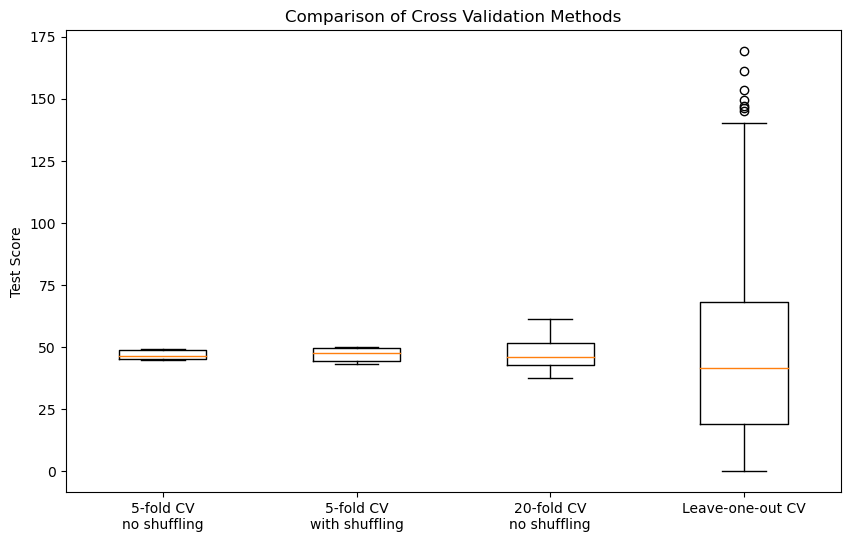

In [48]:
plt.figure(figsize=(10, 6))
plt.boxplot([-res_cv1['test_score'], -res_cv2['test_score'], -res_cv3['test_score'], -res_cv4['test_score']])
plt.xticks([1, 2, 3, 4], ['5-fold CV\nno shuffling', '5-fold CV\nwith shuffling', '20-fold CV\nno shuffling', 'Leave-one-out CV'])
plt.ylabel('Test Score')
plt.title('Comparison of Cross Validation Methods')

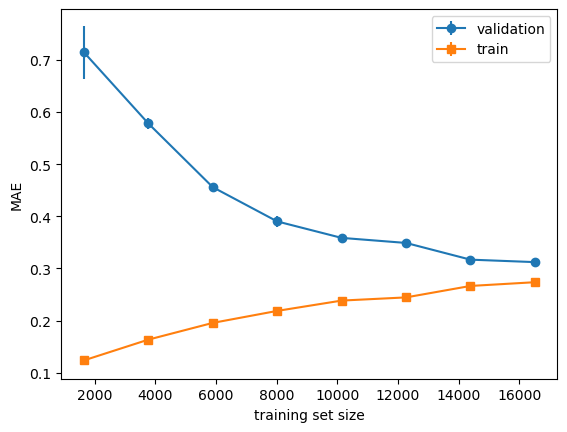

In [5]:
# --- D2: learning curve ---
sizes, train_scores, val_scores = learning_curve(
    model, X, y, cv=cv,
    scoring="neg_mean_absolute_error",
    train_sizes=np.linspace(0.1, 1.0, 8))

train_mae, val_mae = -train_scores, -val_scores

plt.errorbar(sizes, val_mae.mean(1), yerr=val_mae.std(1),
             marker="o", label="validation")
plt.errorbar(sizes, train_mae.mean(1), yerr=train_mae.std(1),
             marker="s", label="train")
plt.xlabel("training set size"); plt.ylabel("MAE"); plt.legend()
plt.show()

In [23]:
from sklearn.model_selection import KFold

X = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
kf = KFold(n_splits=7, shuffle=True, random_state=42)
for train_index, test_index in kf.split(X):
    print("Train Index:", train_index, "Test Index:", test_index)

Train Index: [0 2 3 4 5 6 7 9] Test Index: [1 8]
Train Index: [1 2 3 4 6 7 8 9] Test Index: [0 5]
Train Index: [0 1 3 4 5 6 8 9] Test Index: [2 7]
Train Index: [0 1 2 3 4 5 6 7 8] Test Index: [9]
Train Index: [0 1 2 3 5 6 7 8 9] Test Index: [4]
Train Index: [0 1 2 4 5 6 7 8 9] Test Index: [3]
Train Index: [0 1 2 3 4 5 7 8 9] Test Index: [6]
